In [309]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt

import obspy
from obspy import read
from obspy.clients.fdsn import Client

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import time
import utm
import os
from tqdm import trange

In [411]:

project_name = 'example_salton_sea'

starttime = obspy.UTCDateTime("2024-01-01")
endtime = obspy.UTCDateTime("2025-01-01")

max_dist_deg = 1.0
max_dist_km = 100.0

nbulk = 100

pre_origin_time_buffer = 5.0
post_origin_time_length = 55.0

Fs_resample = 100.0
Fs_min = 80.0
tdif = -0.15

window_len_sec = 1.5

save_waveforms = True

os.makedirs('projects', exist_ok=True)
os.makedirs(f'projects/{project_name}', exist_ok=True)
os.makedirs(f'projects/{project_name}/waveforms', exist_ok=True)
os.makedirs(f'projects/{project_name}/spectra', exist_ok=True)

tt_file_p = f'projects/{project_name}/models/salton.ttP'
tt_file_s = f'projects/{project_name}/models/salton.ttS'

XX,ZZ,Tp = load_tt(tt_file_p)
XX,ZZ,Ts = load_tt(tt_file_s)

nwin = int(window_len_sec*Fs_resample)


In [ ]:

def catalog_to_dataframe(cat, client):

    if 'ncedc' in client.base_url:
        split_char = "/"
    elif 'iris' in client.base_url:
        split_char = "="
    # Lists to hold the extracted data
    event_ids = []
    origin_times = []
    qlats = []
    qlons = []
    qdeps = []
    qmags = []
    qmagtypes = []
    
    for event in cat:
        # Extracting origin information
        origin = event.origins[0] if event.origins else None
        if origin:
            if origin.depth:
                # Extracting event ID
                event_ids.append(event.resource_id.id.split(split_char)[-1])
                # print(origin)
                origin_times.append(origin.time.datetime)
                qlats.append(origin.latitude)
                qlons.append(origin.longitude)
                qdeps.append(origin.depth / 1000)  # Convert depth to km
                
                # Extracting magnitude information
                magnitude = event.magnitudes[0] if event.magnitudes else None
                if magnitude:
                    qmags.append(magnitude.mag)
                    qmagtypes.append(magnitude.magnitude_type)
                else:
                    qmags.append(None)
                    qmagtypes.append(None)
    
    # Creating the DataFrame
    df = pd.DataFrame({
        'event_id': event_ids,
        'origin_time': origin_times,
        'qlat': qlats,
        'qlon': qlons,
        'qdep': qdeps,
        'qmag': qmags,
        'qmagtype': qmagtypes
    })
    
    return df

def inventory_to_dataframe(inventory):
    # Lists to hold the extracted data
    networks = []
    stations = []
    locations = []
    channels = []
    slats = []
    slons = []
    seles = []
    sampling_rates = []
    units = []

    if len(inventory[0][0]) >0:
        for network in inventory:
            for station in network:
                for channel in station:
                    networks.append(network.code)
                    stations.append(station.code)
                    locations.append(channel.location_code)
                    channels.append(channel.code)
                    slats.append(station.latitude)
                    slons.append(station.longitude)
                    seles.append(station.elevation)
                    sampling_rates.append(channel.sample_rate)
                    units.append(channel.response.instrument_sensitivity.input_units)
    
    else:
        for network in inventory:
            for station in network:
                networks.append(network.code)
                stations.append(station.code)
                locations.append("")
                channels.append("")
                slats.append(station.latitude)
                slons.append(station.longitude)
                seles.append(station.elevation)
                sampling_rates.append("")
                units.append("")
    
    # Creating the DataFrame
    df = pd.DataFrame({
        'net': networks,
        'sta': stations,
        'loc': locations,
        'cha': channels,
        'slat': slats,
        'slon': slons,
        'sele': seles,
        'sampling_rate': sampling_rates,
        'units': units
    })
    
    return df

def make_bulks(inv, starttime, endtime, nbulk):
    # https://docs.obspy.org/packages/autogen/obspy.clients.fdsn.client.Client.get_waveforms_bulk.html
    
    # compute number of bulks
    n = (np.ceil(len(inv)/nbulk)).astype(int)
    
    bulks = [[]] * n 
    
    for i in range(n):
        i1 = i*nbulk
        i2 = (i+1)*nbulk # end case?
        bulk_inv = inv[i1:i2].reset_index(drop=True, inplace=False)
        # print(len(bulk_inv))

        if len(bulk_inv) < nbulk:
            i2 = i*nbulk + len(bulk_inv)

        bulk = [()] * int(i2-i1)
        for j, row in bulk_inv.iterrows():
            bulk[j] = (row['net'], row['sta'], row['loc'], row['cha'], starttime, endtime)

        bulks[i] = bulk

    return bulks

def load_tt(path):
    """
    Returns distance, depth, and travel time (array, array, matrix)

    Parameters
    ----------
    path : string
        path (including filename) to travel time table.

    Returns
    -------
    X : np.array
        distances.
    Y : np.array
        depths.
    T : np.array
        travel time matrix.

    """
    # these are properties of the tt tables generated by Peter Shearer's fortran codes
    n_head_lines = 3
    n_foot_lines = 1
    n_skip = n_head_lines+n_foot_lines
    
    # open file
    fp = open(path,'r')
    lines = fp.readlines()
    
    # get header lines
    head = lines[0]
    head2 = lines[1]
    
    # get dimensions of T
    nd = np.array(head2.split(),dtype=int)
    nx = nd[0]
    ny = nd[1]
    
    # init arrays
    X = np.array([],dtype=float)
    Y = np.array(lines[n_head_lines-1].split(),dtype=float)
    T = np.zeros((nx,ny),dtype=float)
    
    for ii,line in enumerate(lines[n_head_lines:]):
        ln = np.array(line.split(),dtype=float)
        X = np.append(X,ln[0])
        T[ii,:] = ln[1:]
            
    return X,Y,T


def get_pick_estimate(X, Y, TT, distance, depth, distance_units='km'):
    """Get an estimated pick time for a given event-station distance 
    and event depth using a travel time table.

    This is designed to interpolate travel times from Peter's traveltime
    codes. X, Y, and TT are np.ndarray objects output from the load_tt()
    function in stressdrop_file_IO.py. See interpolate_grid() for more 
    detailed information.

    Args:
        X (np.ndarray): Distance spacing array
        Y (np.ndarray): Depth spacing array
        TT (np.ndarray): Estimated travel times for given X and Y points
        distance (float): Event-station distance (km or degrees)
        depth (float): Event depth (km)
        distance_units (str, optional): Distance units, either 'km' or 
            'degrees'. Defaults to 'km'.

    Returns:
        Tinterp (float): Estimated travel time

    Sources:

    Last Modified:
        2024-02-06
    """

    dx = X[1] - X[0]
    dy = Y[1] - Y[0]

    if distance_units=='degrees':
        from obspy.geodetics import degrees2kilometers
        distance = degrees2kilometers(distance)
    
    try:
        # get indices of the element to the left of the value in the X and Y
        # directions. Ex: for X = [0, 1, 2, 3] and distance = 1.12, ix = 1
        ix = np.abs(X - distance).argmin()
        iy = np.abs(Y - depth).argmin()
        if distance < (ix * dx): ix -= 1
        if depth <= (iy * dy): iy -= 1

        # get left and right element relative to actual value
        xx = X[ix:ix+2]
        yy = Y[iy:iy+2]
        
        # get 4 elements surrounding actual value
        tt = TT[ix:ix+2,iy:iy+2]

        # notation: T0p: T at x[0], Yp or T(x[0], Yp)
        # Tij = T(xi, yj)
        T0p = ((tt[0,1]-tt[0,0]) / dy ) * (depth - yy[0]) + tt[0,0] #top
        T1p = ((tt[1,1]-tt[1,0]) / dy ) * (depth - yy[0]) + tt[1,0] #bottom
        Tp0 = ((tt[1,0]-tt[0,0]) / dx ) * (distance - xx[0]) + tt[0,0] #left
        Tp1 = ((tt[1,1]-tt[0,1]) / dx ) * (distance - xx[0]) + tt[0,1] #right

        # interpolate along midlines
        Tpx = ((T1p - T0p)/ dx ) * (distance - xx[0]) + T0p
        Tpy = ((Tp1 - Tp0)/ dy ) * (depth - yy[0]) + Tp0
        
        Tinterp = (Tpx+Tpy)/2
    except Exception as E:
        print(E)
        print(f"depth: {depth:.2f}")
        print(f"distance: {distance:.2f}")
        print(f"xx: {xx}")
        print(f"yy: {yy}")
        print(f"tt: {tt}")
        Tinterp = -99999.0
    return Tinterp


In [176]:
station_latlon = (33.0, -115.7588) 
channels = ["HHN","HHE","HHZ","HNE","HNN","HNZ"]

client = Client("IRIS")

# get all stations within 1.5 degrees of station_latlon
inventory = client.get_stations(
    network='*',
    station='*',
    location='*',
    level='channel',
    channel=','.join(channels),
    latitude=station_latlon[0],
    longitude=station_latlon[1],
    maxradius=1.5,
    minradius=0,
    starttime=starttime,
    endtime=endtime)

inv = inventory_to_dataframe(inventory)

inv['sx'], inv['sy'], zn, zl = utm.from_latlon(
    inv['slat'].values, 
    inv['slon'].values
    )

# warn if zn, zl len > 1 ?

In [442]:
# download event catalog for salton sea
client = Client("SCEDC")
# salton sea
event_lon_range = [-115.8588-0.3, -115.8588+0.5]
event_lat_range = [32.5, 33.5]

t0 = time.time()
print("Downloading events...", end='')
catalog = client.get_events(
    minlatitude=event_lat_range[0],
    maxlatitude=event_lat_range[1],
    minlongitude=event_lon_range[0],
    maxlongitude=event_lon_range[1],
    starttime=obspy.UTCDateTime("2024-01-01"),
    endtime=obspy.UTCDateTime("2025-01-01"),
    minmagnitude=3.5,
    includearrivals=True,)

print(f"Done. t = {time.time()-t0:.2f} s")

t0 = time.time()
print("Converting to DataFrame..", end='')
cat = catalog_to_dataframe(catalog, client)
cat['qx'], cat['qy'], qn, ql = utm.from_latlon(
    cat['qlat'].values, 
    cat['qlon'].values
)
print(f"Done. t = {time.time()-t0:.2f} s")


Converting to DataFrame..

UnboundLocalError: cannot access local variable 'split_char' where it is not associated with a value

In [445]:
catalog[0].picks

[Pick
	       resource_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?assocaro=417872572")
	              time: UTCDateTime(2024, 6, 23, 19, 17, 3, 590000)
	       waveform_id: WaveformStreamID(network_code='CI', station_code='SAL', channel_code='EHZ', location_code='')
	             onset: 'impulsive'
	        phase_hint: 'P'
	          polarity: 'positive'
	   evaluation_mode: 'manual'
	 evaluation_status: 'reviewed'
	     creation_info: CreationInfo(agency_id='CI', creation_time=UTCDateTime(2024, 6, 23, 20, 16, 20)),
 Pick
	       resource_id: ResourceIdentifier(id="quakeml:service.scedc.caltech.edu/fdsnws/event/1/query?assocaro=417872580")
	              time: UTCDateTime(2024, 6, 23, 19, 17, 5, 950000)
	       waveform_id: WaveformStreamID(network_code='CI', station_code='SAL', channel_code='HNN', location_code='')
	             onset: 'impulsive'
	        phase_hint: 'S'
	          polarity: 'undecidable'
	   evaluation_mode: 'manual'
	 evaluati

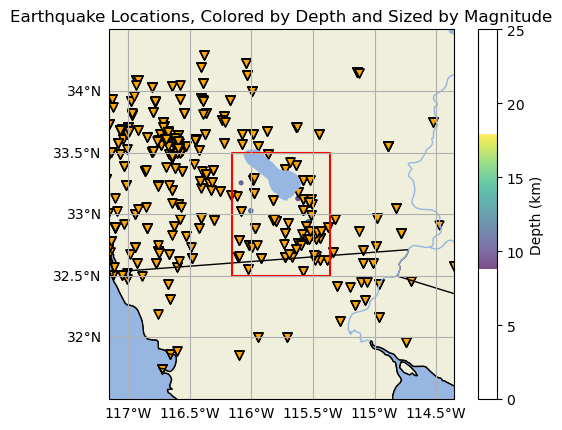

In [178]:
colors = ['orange', 'b', 'g', 'r', 'c', 'm', 'y', 'gray', 'orange', 'pink', 'brown', 'purple', 'olive', 'teal']

proj = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent([event_lon_range[0]-1, event_lon_range[1]+1, event_lat_range[0]-1, event_lat_range[1]+1])

ax.add_feature(cfeature.LAND, edgecolor='k')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.RIVERS)

# draw box around event region
box_lon = [
    event_lon_range[0],
    event_lon_range[1],
    event_lon_range[1],
    event_lon_range[0],
    event_lon_range[0]
]

box_lat = [
    event_lat_range[0],
    event_lat_range[0],
    event_lat_range[1],
    event_lat_range[1],
    event_lat_range[0]
]
ax.plot(box_lon, box_lat, c='r')


# inland seas
ax.add_feature(cfeature.LAKES)
# ax.add_feature(cfeature.LAKES.with_scale('50m'))

# plot events from catalog
sc = ax.scatter(cat['qlon'], cat['qlat'], c=cat['qdep'], s=cat['qmag']*2, cmap='viridis', transform=proj, alpha=0.7)
cb = plt.colorbar(sc, ax=ax, orientation='vertical', label='Depth (km)')
cb.set_label('Depth (km)')

ax.scatter(inv['slon'], inv['slat'], c='orange', s=40, marker='v', edgecolors='k', transform=proj)


# flip cb
cb.ax.invert_yaxis()
cb.ax.set_ylim((0, 25))


# Setting the title
plt.title('Earthquake Locations, Colored by Depth and Sized by Magnitude')

# Adding gridlines and labels for lat/lon tick marks
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

# Display the plot
plt.show()


In [ ]:
# for each event, download waveforms

for i, row in cat.iterrows():
    t0 = time.time()
    print(f"Downloading data for event {i}/{len(cat)}: {row['event_id']}")

    # first, get stations within max_dist of event:
    # rough filter for speed?
    # ev_inv = inv[
    #     np.logical_and(
    #         np.abs(inv['sx']-row['qx']) < max_dist_km * 1000.0,
    #         np.abs(inv['sy']-row['qy']) < max_dist_km * 1000.0
    #         )
    #     ]
    
    # filter inv to stations within max_dist
    ev_inv = inv[
        np.sqrt((inv['sx']-row['qx'])**2 + (inv['sy']-row['qy'])**2) < max_dist_km * 1000.0
    ].reset_index(drop=True, inplace=False)

    ev_origin_time = obspy.UTCDateTime(row['origin_time'])

    wv_starttime = ev_origin_time - pre_origin_time_buffer
    wv_endtime = ev_origin_time + post_origin_time_length

    bulks = make_bulks(ev_inv, wv_starttime, wv_endtime, nbulk)

    ST = obspy.core.stream.Stream(traces=None)
    for bulk in bulks:
        try:
            ST = ST + client.get_waveforms_bulk(bulk, attach_response=True)
        except:
            print('', end='')

    st = ST.copy()
    # st = client.get_waveforms(
    #     network='*',
    #     station='*',
    #     location='*',
    #     channel='*',
    #     starttime=ev_starttime,
    #     endtime=ev_endtime,
    #     maxradius=max_dist_deg,
    #     minradius=0
        
    # )
    raise ValueError()


ValueError: 

In [250]:
row

event_id                         11855626
origin_time    2024-06-23 19:17:01.080000
qlat                               33.255
qlon                          -116.083833
qdep                                10.55
qmag                                 3.59
qmagtype                               Ml
qx                          585338.924162
qy                         3679931.011517
Name: 0, dtype: object

In [436]:
units

'm/s'

In [438]:
'm/' in units

True

-0.0045000000000001705


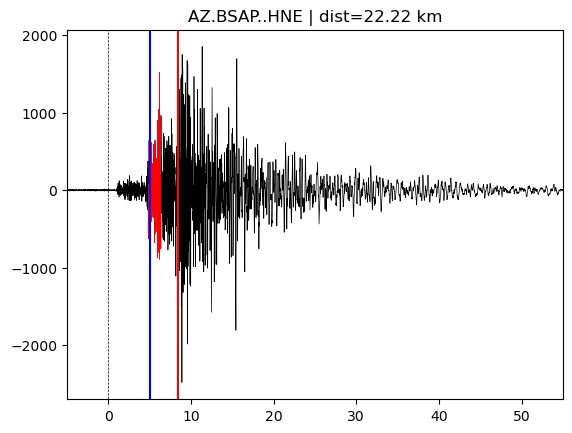

-0.0045000000000001705


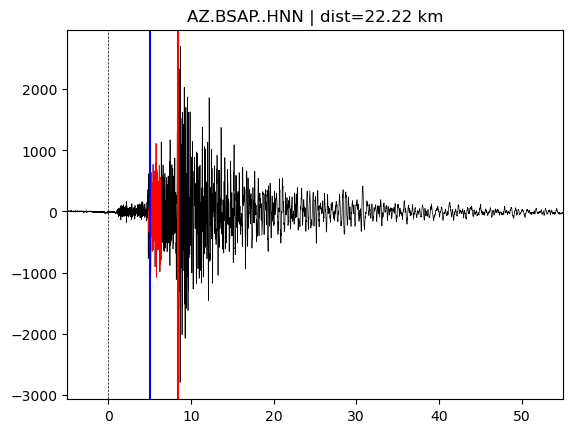

-0.0045000000000001705


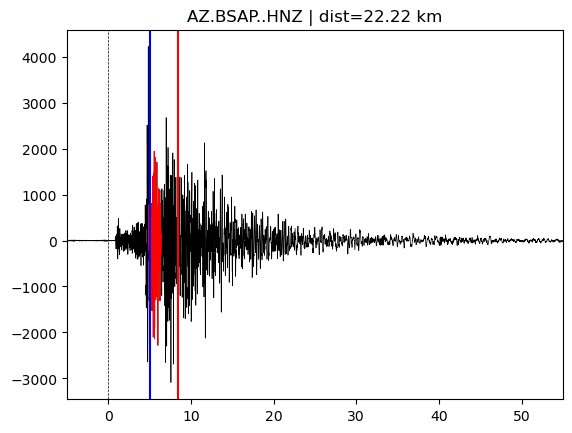

-0.008399999999999963


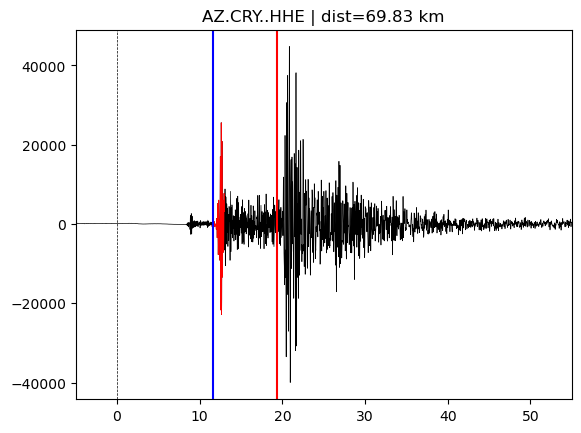

-0.008399999999999963


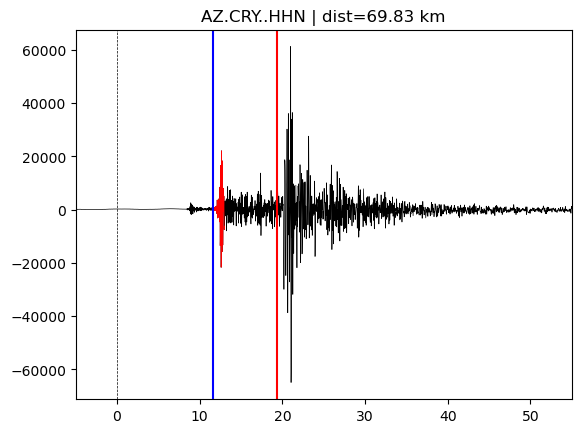

-0.008399999999999963


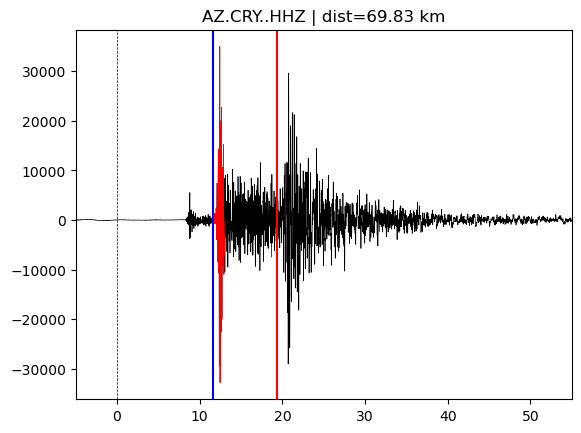

-0.008399999999999963


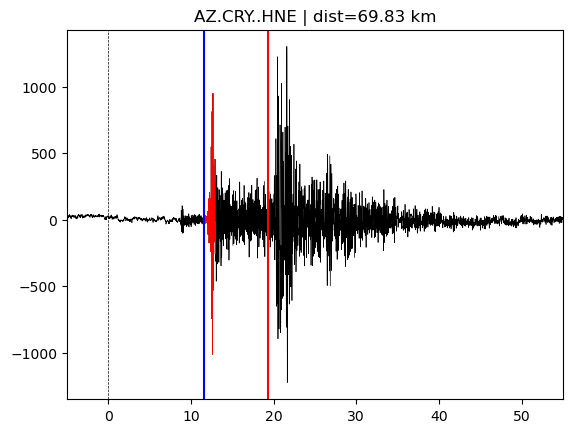

ValueError: 

In [439]:
st = ST.copy()

# st = st.select(component='Z')

st.detrend(type='demean')
st.resample(Fs_resample)

# st.taper(0.25, type='hann', side='both')
# st.filter('highpass', freq=1.0)


for i, tr in enumerate(st):

    # first, estimate arrival time:
    srow = inv.loc[
        (inv['net'] == tr.stats.network) & 
        (inv['sta'] == tr.stats.station)
        ]
    sx = srow['sx'].values[0]
    sy = srow['sy'].values[0]
    units = srow['units'].values[0].lower()
    # print(units)

    if 'mm' in units:
        tr.data = tr.data * 1000.0

    deldist = np.sqrt((row['qx']-sx)**2 + (row['qy']-sy)**2) / 1000.0

    st[i].stats.distance = deldist * 1000.0

    pick_p = get_pick_estimate(XX, ZZ, Tp, deldist, row['qdep'])
    pick_s = get_pick_estimate(XX, ZZ, Ts, deldist, row['qdep'])

    t = tr.times() - pre_origin_time_buffer

    # index of first point in signal window:
    # datetime of window start:ev_origin_time + tdif
    it0 = np.argmin(np.abs(t-(tdif + pick_p)))


    print(ev_origin_time - tr.stats.starttime - pre_origin_time_buffer)
    # print(i, deldist)

    # get the arrival time:
    # arrivals = velocity_model.get_travel_times(source_depth_in_km=row['qdep'], distance_in_degree=deldist / 111.0,
    #     phase_list=('P','S','p','s'))
    # print(arrivals)

    # print(f'd={deldist:.2f}: {pick_p:.2f}, {pick_s:.2f}')

    # if len(tr.times()) < 5000:
    fig = plt.figure()
    # tr.plot(fig=fig)
    # plt.axvline(ev_origin_time, c='k', ls='--')
    # plt.axvline(ev_origin_time+pick_p, c='b')
    # plt.axvline(ev_origin_time+pick_s, c='r')
    # plt.xlim([ev_origin_time - pre_origin_time_buffer, ev_origin_time + post_origin_time_length])

    plt.plot(t, tr.data, c='k', lw=0.5)
    plt.plot(t[it0:it0+nwin], tr.data[it0:it0+nwin], c='r', lw=0.5)
    plt.axvline(0, c='k', ls='--', lw=0.5)
    plt.axvline(pick_p, c='b')
    plt.axvline(pick_s, c='r')
    plt.xlim([-pre_origin_time_buffer, post_origin_time_length])
    plt.title(f"{tr.id} | dist={deldist:.2f} km")

    plt.show()

    if i > 5:
        raise ValueError()

# fig = plt.figure()

# dists = np.linspace(0, 100, 101)
# ttp = np.zeros(101)
# tts = np.zeros(101)
# for i, d in enumerate(dists):
#     ttp[i] = get_pick_estimate(XX, ZZ, Tp, d, row['qdep'])
#     tts[i] = get_pick_estimate(XX, ZZ, Ts, d, row['qdep'])

# st.plot(type='section', scale=4, fig=fig)

# plt.plot(dists, ttp+pre_origin_time_buffer, c='b')
# plt.plot(dists, tts+pre_origin_time_buffer, c='r')
# plt.show()


In [ ]:
it0 = np.argmin(np.abs(tr.times()-(ev_origin_time - tr.stats.starttime + tdif)))

485

In [400]:
inv

,net,sta,loc,cha,slat,slon,sele,sampling_rate,units,sx,sy
0,AZ,BSAP,,HNE,33.260201,-116.322304,160.0,200.0,M/S**2,563121.649417,3.680338e+06
1,AZ,BSAP,,HNN,33.260201,-116.322304,160.0,200.0,M/S**2,563121.649417,3.680338e+06
2,AZ,BSAP,,HNZ,33.260201,-116.322304,160.0,200.0,M/S**2,563121.649417,3.680338e+06
3,AZ,BZN,,HHE,33.491500,-116.667000,1301.0,100.0,m/s,530933.921110,3.705826e+06
4,AZ,BZN,,HHN,33.491500,-116.667000,1301.0,100.0,m/s,530933.921110,3.705826e+06
...,...,...,...,...,...,...,...,...,...,...,...
2129,ZY,COON,,HNN,32.753899,-115.950897,78.0,100.0,M/S**2,598276.297786,3.624492e+06
2130,ZY,COON,,HNZ,32.753899,-115.950897,78.0,100.0,M/S**2,598276.297786,3.624492e+06
2131,ZY,MGD,,HNE,32.188801,-116.760597,1300.0,100.0,M/S**2,522566.461780,3.561388e+06
2132,ZY,MGD,,HNN,32.188801,-116.760597,1300.0,100.0,M/S**2,522566.461780,3.561388e+06


In [389]:
[len(tr) for tr in st]

[6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 5999,
 5999,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6001,
 6001,
 6001,
 6001,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6001,
 292,
 3400,
 1509,
 292,
 3300,
 1409,
 6001,
 6001,
 6001,
 6001,
 6001,
 6001,
 6001,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6001,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 6000,
 5999]

In [278]:
arrivals

[<obspy.taup.helper_classes.Arrival object at 0x1712834d0>, <obspy.taup.helper_classes.Arrival object at 0x171282360>, <obspy.taup.helper_classes.Arrival object at 0x171134950>, <obspy.taup.helper_classes.Arrival object at 0x1711663f0>, <obspy.taup.helper_classes.Arrival object at 0x171282d80>, <obspy.taup.helper_classes.Arrival object at 0x171239400>]

In [286]:
arrivals = velocity_model.get_travel_times(source_depth_in_km=row['qdep'], distance_in_degree=100 / 111.0)
print(arrivals)

27 arrivals
	P phase arrival at 15.579 seconds
	Pn phase arrival at 16.898 seconds
	pP phase arrival at 19.311 seconds
	PP phase arrival at 19.675 seconds
	pP phase arrival at 20.778 seconds
	PP phase arrival at 20.813 seconds
	sP phase arrival at 21.125 seconds
	SP phase arrival at 27.455 seconds
	Sn phase arrival at 28.165 seconds
	sS phase arrival at 32.191 seconds
	SS phase arrival at 32.798 seconds
	sS phase arrival at 34.637 seconds
	SS phase arrival at 34.695 seconds
	PcP phase arrival at 508.567 seconds
	ScP phase arrival at 718.789 seconds
	PcS phase arrival at 720.368 seconds
	ScS phase arrival at 930.600 seconds
	PKiKP phase arrival at 991.838 seconds
	pPKiKP phase arrival at 996.568 seconds
	sPKiKP phase arrival at 998.146 seconds
	SKiKP phase arrival at 1202.049 seconds
	PKIKKIKP phase arrival at 1910.154 seconds
	SKIKKIKP phase arrival at 2120.365 seconds
	PKIKKIKS phase arrival at 2121.943 seconds
	SKIKKIKS phase arrival at 2332.154 seconds
	PKIKPPKIKP phase arrival at 2

In [296]:
for i in range(len(arrivals)):
    arr = arrivals[i]
    print(arr.phase.name, arr.time)

P 15.578610578929844
Pn 16.897736470188008
pP 19.311182071623676
PP 19.67470219660251
pP 20.777941365562434
PP 20.813137254963014
sP 21.12524994519546
SP 27.454892877784484
Sn 28.16501376715456
sS 32.19148648706409
SS 32.7975777428672
sS 34.63667385586289
SS 34.69529388958087
PcP 508.5671248638198
ScP 718.7892401053707
PcS 720.3676585454771
ScS 930.5995404290004
PKiKP 991.8378872844402
pPKiKP 996.5677354093567
sPKiKP 998.1461436886829
SKiKP 1202.0489412502104
PKIKKIKP 1910.1540053604515
SKIKKIKP 2120.3650229241675
PKIKKIKS 2121.9434311800505
SKIKKIKS 2332.1544022913854
PKIKPPKIKP 2421.044157894565
SKIKSSKIKS 3266.6242327593836


In [ ]:
arr.phase, arr.time

TypeError: 'SeismicPhase' object is not callable

In [247]:
inv[(inv['net'] == 'SB') & (inv['sta'] == 'WLA10')]

,net,sta,loc,cha,slat,slon,sele,sampling_rate,units,sx,sy


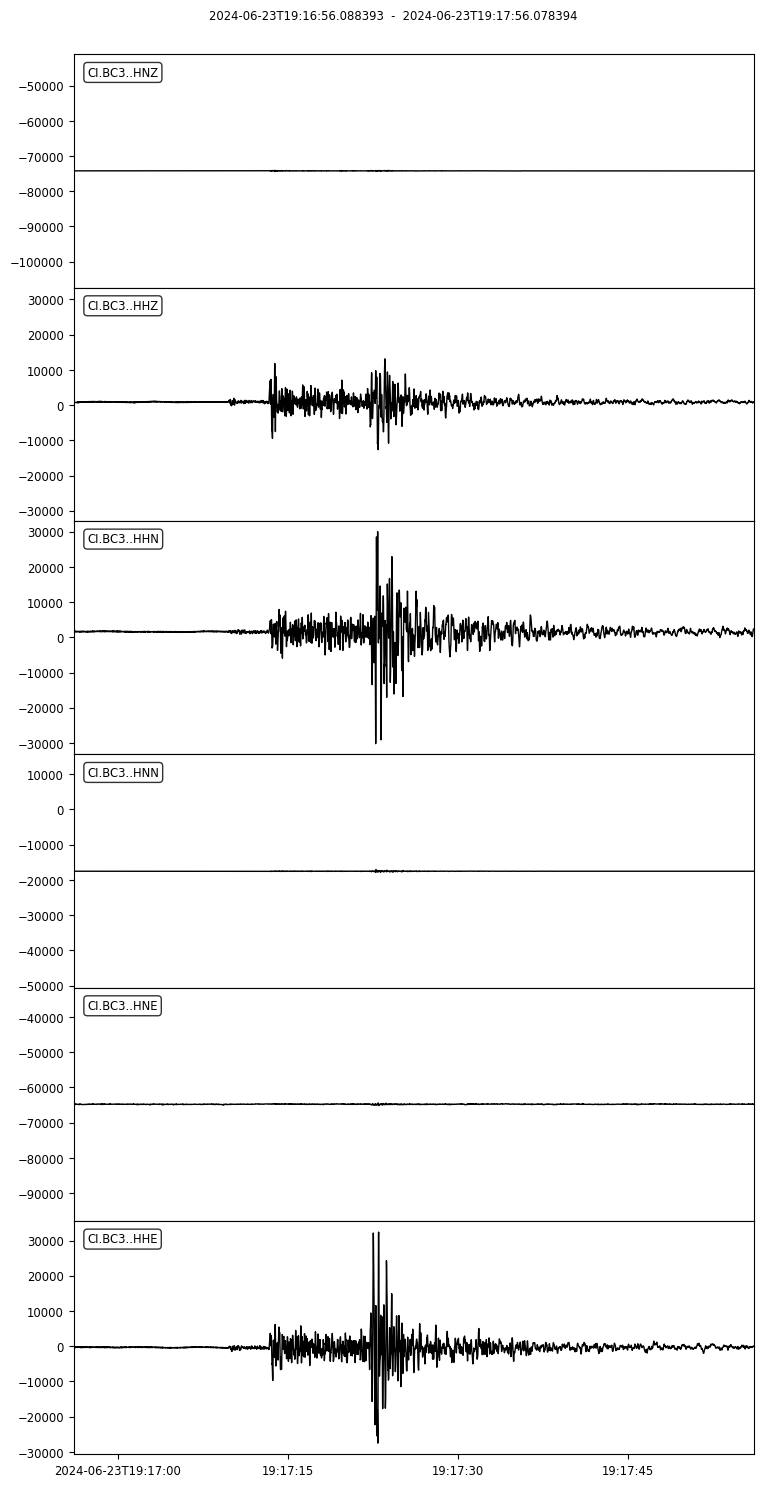

NameError: name 'tr2' is not defined

In [ ]:
from obspy.signal.trigger import ar_pick

unique_stations = np.unique([tra.stats.station for tra in st.traces])

for sta in unique_stations:
    st_trig = st.select(station=sta)

    st_trig.plot()

    df = tr1.stats.sampling_rate

    p_pick, s_pick = ar_pick(tr1.data, tr2.data, tr3.data, df,
                            1.0, 20.0, 1.0, 0.1, 4.0, 1.0, 2, 8, 0.1, 0.2)

In [203]:
from obspy.taup import TauPyModel

model = TauPyModel(model="iasp91")

arrivals = model.get_travel_times(source_depth_in_km=1,
                                  distance_in_degree=.5,
                                  phase_list=['P','S','p','s'])

In [204]:
print(arrivals)

2 arrivals
	p phase arrival at 9.587 seconds
	s phase arrival at 16.548 seconds


In [307]:
from obspy.taup import taup_create
taup_create.build_taup_model(filename=f'projects/{project_name}/models/iaspei91_salton.tvel',output_folder=f'projects/{project_name}/models')

velocity_model = TauPyModel(model=f'projects/{project_name}/models/iaspei91_salton.npz')


Building obspy.taup model for 'projects/example_salton_sea/models/iaspei91_salton.tvel' ...
filename = projects/example_salton_sea/models/iaspei91_salton.tvel
Done reading velocity model.
Radius of model  is 6371.0
Using parameters provided in TauP_config.ini (or defaults if not) to call SlownessModel...
Parameters are:
taup.create.min_delta_p = 0.1 sec / radian
taup.create.max_delta_p = 11.0 sec / radian
taup.create.max_depth_interval = 115.0 kilometers
taup.create.max_range_interval = 0.04363323129985824 degrees
taup.create.max_interp_error = 0.05 seconds
taup.create.allow_inner_core_s = True
Slow model  830 P layers,848 S layers
Done calculating Tau branches.
Done Saving projects/example_salton_sea/models/iaspei91_salton.npz
Method run is done, but not necessarily successful.


In [ ]:


# generate traveltime tables for P and S waves

dx = 1.0
dz = 1.0

xmax = 150.0
zmax = 28.0

X = np.linspace(0, xmax, int(xmax/dx + 1))
Z = np.linspace(0, zmax, int(zmax/dz + 1))

nx = len(X)
nz = len(Z)

Tp = np.zeros((len(Z), len(X)), dtype=float)
Ts = np.zeros((len(Z), len(X)), dtype=float)

print("Computing P-wave travel times...")
for i in trange(nx):
    x = X[i]
    for j, z in enumerate(Z):
        arrivals = velocity_model.get_travel_times(source_depth_in_km= z,
                                                  distance_in_degree= x / 111.0,
                                                  phase_list=['p', 'P'])
        # if z > 10:
        #     raise ValueError()
        
        phases = [arr.phase.name for arr in arrivals]

        if 'p' in phases:
            ip = phases.index('p')
            Tp[j,i] = arrivals[ip].time
        else:
            ip = phases.index('P')
            Tp[j,i] = arrivals[ip].time

with open(tt_file_p, 'w') as fp:
    fp.write(f'From obspy.taup, file = iaspei91_salton.tvel\n')
    fp.write(f"{nx:4d} {nz:4d}\n")

    fp.write("         ")
    for j in range(nz):
        fp.write(f" {Z[j]:8.1f}")
    fp.write("\n")
    
    for i in range(nx):
        fp.write(f" {X[i]:8.1f}")
        for j in range(nz):
            fp.write(f" {Tp[j,i]:8.3f}")
        fp.write("\n")

print("Computing S-wave travel times...")
for i in trange(nx):
    x = X[i]
    for j, z in enumerate(Z):
        arrivals = velocity_model.get_travel_times(source_depth_in_km= z,
                                                  distance_in_degree= x / 111.0,
                                                  phase_list=['s', 'S'])
        # if z > 10:
        #     raise ValueError()
        
        phases = [arr.phase.name for arr in arrivals]

        if 's' in phases:
            iS = phases.index('s')
            Ts[j,i] = arrivals[iS].time
        else:
            iS = phases.index('S')
            Ts[j,i] = arrivals[iS].time

with open(tt_file_s, 'w') as fp:
    fp.write(f'From obspy.taup, file = iaspei91_salton.tvel\n')
    fp.write(f"{nx:4d} {nz:4d}\n")

    fp.write("         ")
    for j in range(nz):
        fp.write(f" {Z[j]:8.1f}")
    fp.write("\n")
    
    for i in range(nx):
        fp.write(f" {X[i]:8.1f}")
        for j in range(nz):
            fp.write(f" {Ts[j,i]:8.3f}")
        fp.write("\n")

100%|██████████| 151/151 [01:47<00:00,  1.41it/s]


In [350]:

# generate traveltime tables for P and S waves

dx = 1.0
dz = 1.0

xmax = 150.0
zmax = 28.0

X = np.linspace(0, xmax, int(xmax/dx + 1))
Z = np.linspace(0, zmax, int(zmax/dz + 1))

nx = len(X)
nz = len(Z)

Tp = np.zeros((len(Z), len(X)), dtype=float)
Ts = np.zeros((len(Z), len(X)), dtype=float)

print("Computing S-wave travel times...")
for i in trange(nx):
    x = X[i]
    for j, z in enumerate(Z):
        arrivals = velocity_model.get_travel_times(source_depth_in_km= z,
                                                  distance_in_degree= x / 111.0,
                                                  phase_list=['s', 'S', 'sP', 'SS'])
        # if z > 10:
        #     raise ValueError()
        
        phases = [arr.phase.name for arr in arrivals]

        iS = np.nan
        if 's' in phases:
            iS = phases.index('s')
        elif 'S' in phases:
            iS = phases.index('S')
        elif 'SS' in phases:
            iS = phases.index('SS')
        elif 'sP' in phases:
            iS = phases.index('sP')

        t = np.array(arrivals[iS].time)
        if t.size >1: t = t[0]
        Ts[j,i] = arrivals[iS].time

with open(tt_file_s, 'w') as fp:
    fp.write(f'From obspy.taup, file = iaspei91_salton.tvel\n')
    fp.write(f"{nx:4d} {nz:4d}\n")

    fp.write("         ")
    for j in range(nz):
        fp.write(f" {Z[j]:8.1f}")
    fp.write("\n")
    
    for i in range(nx):
        fp.write(f" {X[i]:8.1f}")
        for j in range(nz):
            fp.write(f" {Ts[j,i]:8.3f}")
        fp.write("\n")

Computing S-wave travel times...


100%|██████████| 151/151 [03:55<00:00,  1.56s/it]


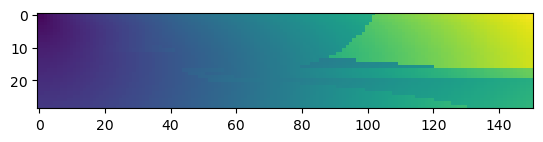

In [352]:
plt.imshow(Ts)

In [348]:
arrivals = velocity_model.get_travel_times(source_depth_in_km= z,
                                                distance_in_degree= x / 111.0
                                                )

In [337]:
z,x

(17.0, 44.0)

In [349]:
print(arrivals)

23 arrivals
	P phase arrival at 17.839 seconds
	Pn phase arrival at 18.973 seconds
	PP phase arrival at 21.873 seconds
	PP phase arrival at 22.382 seconds
	PP phase arrival at 22.680 seconds
	PS phase arrival at 31.200 seconds
	SP phase arrival at 31.200 seconds
	Sn phase arrival at 31.626 seconds
	SS phase arrival at 36.463 seconds
	SS phase arrival at 37.313 seconds
	SS phase arrival at 37.809 seconds
	PcP phase arrival at 510.934 seconds
	PcS phase arrival at 722.736 seconds
	ScP phase arrival at 722.736 seconds
	ScS phase arrival at 934.547 seconds
	PKiKP phase arrival at 994.203 seconds
	SKiKP phase arrival at 1205.993 seconds
	PKIKKIKP phase arrival at 1912.518 seconds
	PKIKKIKS phase arrival at 2124.308 seconds
	SKIKKIKP phase arrival at 2124.308 seconds
	SKIKKIKS phase arrival at 2336.097 seconds
	PKIKPPKIKP phase arrival at 2423.408 seconds
	SKIKSSKIKS phase arrival at 3270.567 seconds
